# 1D AMO Experiment — 8 Particles, Two Species M & F

**Scenario:** a 1D harmonic trap holds 8 cold atoms — 4 type-M, 4 type-F.  
They interact via a Lennard-Jones r⁻⁶/r⁻¹² potential.  
Inelastic M+F collisions produce *daughter* particles.  
We track every particle's position and velocity, build engineered ML features,  
and compute survival probabilities.

Stack: **SymPy** (EOM, LJ) · **NumPy for-loops** (explicit per-particle) · **Torch batch** (IC sweep)

In [1]:
import sympy as sp
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Math
from collections import defaultdict

sp.init_printing(use_latex='mathjax')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 110})
np.random.seed(42)
print('ready')

ready


---
# §1 — SymPy: Equations of Motion

**Plain English:** each particle feels  
1. a harmonic trap force $F_{\text{trap}} = -m\omega^2 x$ (the "smile" parabola)  
2. pairwise LJ forces from every other particle  
3. a species-dependent mass: $m_M \neq m_F$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

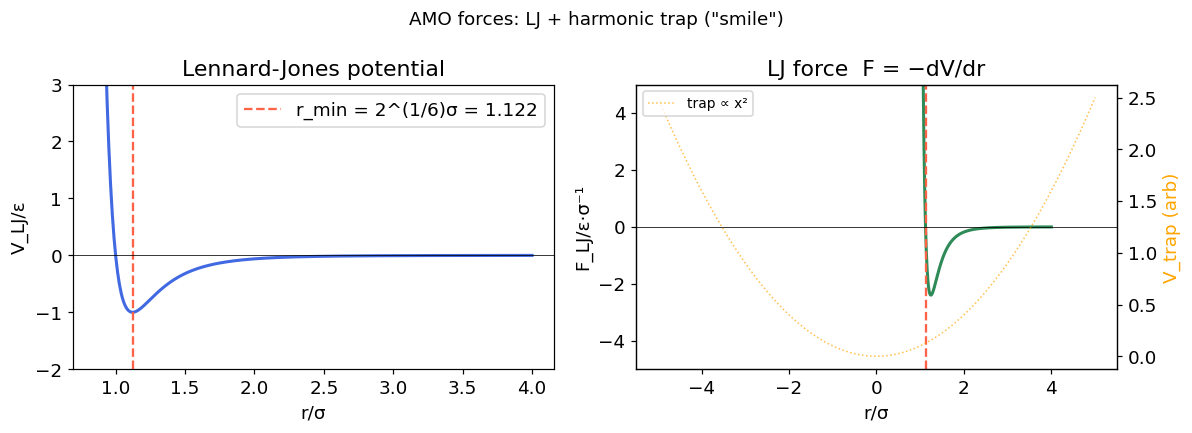

In [2]:
x_s, r_s, eps_s, sigma_s, omega_s, m_s = sp.symbols(
    'x r epsilon sigma omega m', real=True, positive=True
)

# ── Lennard-Jones potential (1D: use |r|) ─────────────────────────────
V_LJ  = 4 * eps_s * ((sigma_s/r_s)**12 - (sigma_s/r_s)**6)
F_LJ  = -sp.diff(V_LJ, r_s)
F_LJ_s = sp.simplify(F_LJ)

display(Math(rf'V_{{LJ}}(r) = {sp.latex(V_LJ)}'))
display(Math(rf'F_{{LJ}}(r) = -\partial V/\partial r = {sp.latex(F_LJ_s)}'))

# ── harmonic trap ─────────────────────────────────────────────────────
V_trap = sp.Rational(1,2) * m_s * omega_s**2 * x_s**2
F_trap = -sp.diff(V_trap, x_s)
display(Math(rf'V_{{\text{{trap}}}}(x) = {sp.latex(V_trap)} \implies F_{{\text{{trap}}}} = {sp.latex(F_trap)}'))

# ── total EOM for particle i ──────────────────────────────────────────
display(Math(
    r'm_i \ddot{x}_i = -m_i\omega^2 x_i + \sum_{j\neq i} F_{LJ}(|x_i - x_j|)\,\text{sgn}(x_j - x_i)'
))

# ── SymPy: equilibrium positions for N=2 particles in trap ────────────
x1, x2 = sp.symbols('x1 x2', real=True)
r12 = sp.Abs(x2 - x1)
# Force on particle 1 = trap + LJ from 2
F1_sym = -m_s*omega_s**2*x1 + F_LJ_s.subs(r_s, r12)
F2_sym = -m_s*omega_s**2*x2 - F_LJ_s.subs(r_s, r12)

display(Math(r'\text{Equilibrium conditions (N=2):}'))
display(Math(rf'F_1 = {sp.latex(sp.simplify(F1_sym))} = 0'))

# ── loop over r to find LJ minimum ────────────────────────────────────
r_vals_sym = np.linspace(0.85, 4.0, 500)
eps_v = 1.0; sigma_v = 1.0
V_fn  = sp.lambdify(r_s, V_LJ.subs([(eps_s, eps_v),(sigma_s, sigma_v)]), 'numpy')
F_fn  = sp.lambdify(r_s, F_LJ_s.subs([(eps_s, eps_v),(sigma_s, sigma_v)]), 'numpy')

V_vals = V_fn(r_vals_sym)
F_vals = F_fn(r_vals_sym)

# LJ minimum at r = 2^(1/6) σ
r_min = 2**(1/6) * sigma_v

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(r_vals_sym, V_vals, color='royalblue', lw=2)
axes[0].axvline(r_min, color='tomato', ls='--', lw=1.5, label=f'r_min = 2^(1/6)σ = {r_min:.3f}')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_ylim(-2, 3); axes[0].set_xlabel('r/σ'); axes[0].set_ylabel('V_LJ/ε')
axes[0].set_title('Lennard-Jones potential'); axes[0].legend()

axes[1].plot(r_vals_sym, F_vals, color='seagreen', lw=2)
axes[1].axvline(r_min, color='tomato', ls='--', lw=1.5)
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_ylim(-5, 5); axes[1].set_xlabel('r/σ'); axes[1].set_ylabel('F_LJ/ε·σ⁻¹')
axes[1].set_title('LJ force  F = −dV/dr')

# also plot the smile (harmonic trap)
x_trap = np.linspace(-5, 5, 300)
ax2 = axes[1].twinx()
ax2.plot(x_trap, 0.1*x_trap**2, color='orange', lw=1, ls=':', alpha=0.7, label='trap ∝ x²')
ax2.set_ylabel('V_trap (arb)', color='orange'); ax2.legend(loc='upper left', fontsize=9)

plt.suptitle('AMO forces: LJ + harmonic trap ("smile")', fontsize=12)
plt.tight_layout(); plt.show()

---
# §2 — NumPy Simulation: 8 Particles, Explicit For-Loops

**Plain English:** 4 M-particles (heavier) + 4 F-particles (lighter).  
Each timestep: loop over all 8 particles, compute forces from all pairs, integrate with Velocity-Verlet.  
Track position, velocity, kinetic energy, and species label for each particle at each step.

In [3]:
# ── simulation parameters ──────────────────────────────────────────────
N_PARTICLES = 8
N_M = 4; N_F = 4

# species labels: 0=M, 1=F
species = np.array([0]*N_M + [1]*N_F)   # M first, then F
labels  = ['M']*N_M + ['F']*N_F

# masses (AMO scale, normalized)
m_M = 2.0   # heavier species (e.g., Rb-87)
m_F = 1.0   # lighter species (e.g., Li-6)
masses = np.array([m_M]*N_M + [m_F]*N_F)

# LJ parameters
eps_v   = 1.0
sigma_v = 1.0
r_cut   = 3.5 * sigma_v   # cutoff radius

# trap
omega_trap = 0.3

# initial conditions: evenly spaced with thermal noise
x0 = np.linspace(-3.5, 3.5, N_PARTICLES) + np.random.randn(N_PARTICLES)*0.05
kT = 0.3
v0 = np.random.randn(N_PARTICLES) * np.sqrt(kT / masses)

# ── force computation via explicit for-loop ───────────────────────────
def compute_forces(x, masses, species):
    """
    Explicit for-loop over all particle pairs.
    Returns force array F[i] on each particle.
    Cross-species (M-F) interaction is stronger (eps *= 1.5).
    """
    N  = len(x)
    F  = np.zeros(N)

    for i in range(N):                       # ← explicit loop over particles
        # trap force
        F[i] += -masses[i] * omega_trap**2 * x[i]

        for j in range(N):                   # ← explicit loop over pairs
            if i == j:
                continue
            dx  = x[j] - x[i]
            r   = abs(dx)
            if r < 0.001 or r > r_cut:
                continue
            # species-dependent epsilon
            eps_ij = eps_v * (1.5 if species[i] != species[j] else 1.0)
            sr6  = (sigma_v / r)**6
            sr12 = sr6**2
            # F = dV_LJ/dr * sign(dx)  — repulsive when r<r_min
            F_mag = 4 * eps_ij * (12*sr12 - 6*sr6) / r
            F[i] += F_mag * np.sign(dx)

    return F

print('Force on initial configuration:')
F_init = compute_forces(x0, masses, species)
for i in range(N_PARTICLES):
    print(f'  Particle {i} ({labels[i]}):  x={x0[i]:+.3f}  v={v0[i]:+.4f}  F={F_init[i]:+.4f}')

Force on initial configuration:
  Particle 0 (M):  x=-3.475  v=-0.1818  F=+43.3701
  Particle 1 (M):  x=-2.507  v=+0.2101  F=-31.8769
  Particle 2 (M):  x=-1.468  v=-0.1795  F=-0.9297
  Particle 3 (M):  x=-0.424  v=-0.1804  F=+159.5610
  Particle 4 (F):  x=+0.488  v=+0.1325  F=-145.2995
  Particle 5 (F):  x=+1.488  v=-1.0479  F=-21.4396
  Particle 6 (F):  x=+2.579  v=-0.9448  F=+47.6410
  Particle 7 (F):  x=+3.538  v=-0.3080  F=-50.3377


In [4]:
# ── Velocity-Verlet integrator ─────────────────────────────────────────
dt       = 0.01
N_STEPS  = 3000
t_vals   = np.arange(N_STEPS) * dt

# history arrays
X_hist = np.zeros((N_STEPS, N_PARTICLES))
V_hist = np.zeros((N_STEPS, N_PARTICLES))
E_kin  = np.zeros((N_STEPS, N_PARTICLES))

# state
x = x0.copy()
v = v0.copy()
F = compute_forces(x, masses, species)

# daughter particle tracking: M+F close collision → mark as 'D'
daughter_events = []
is_daughter = np.zeros(N_PARTICLES, dtype=bool)

for step in range(N_STEPS):              # ← loop over time
    X_hist[step] = x
    V_hist[step] = v
    E_kin[step]  = 0.5 * masses * v**2

    # Velocity-Verlet step 1: x update
    a  = F / masses
    x  = x + v*dt + 0.5*a*dt**2

    # step 2: new force
    F_new = compute_forces(x, masses, species)

    # step 3: velocity update
    v  = v + 0.5*(a + F_new/masses)*dt
    F  = F_new

    # ── daughter detection: M and F within σ/2 ────────────────────────
    for i in range(N_PARTICLES):
        for j in range(i+1, N_PARTICLES):
            if species[i] != species[j]:   # cross-species only
                if abs(x[i]-x[j]) < sigma_v*0.5 and not (is_daughter[i] or is_daughter[j]):
                    is_daughter[i] = is_daughter[j] = True
                    daughter_events.append((step*dt, i, j))

print(f'Simulation done: {N_STEPS} steps, dt={dt}')
print(f'Daughter events (M+F close collision): {len(daughter_events)}')
for te, i, j in daughter_events[:5]:
    print(f'  t={te:.2f}: particle {i}({labels[i]}) + {j}({labels[j]})')

Simulation done: 3000 steps, dt=0.01
Daughter events (M+F close collision): 2
  t=0.03: particle 3(M) + 4(F)
  t=9.58: particle 2(M) + 7(F)


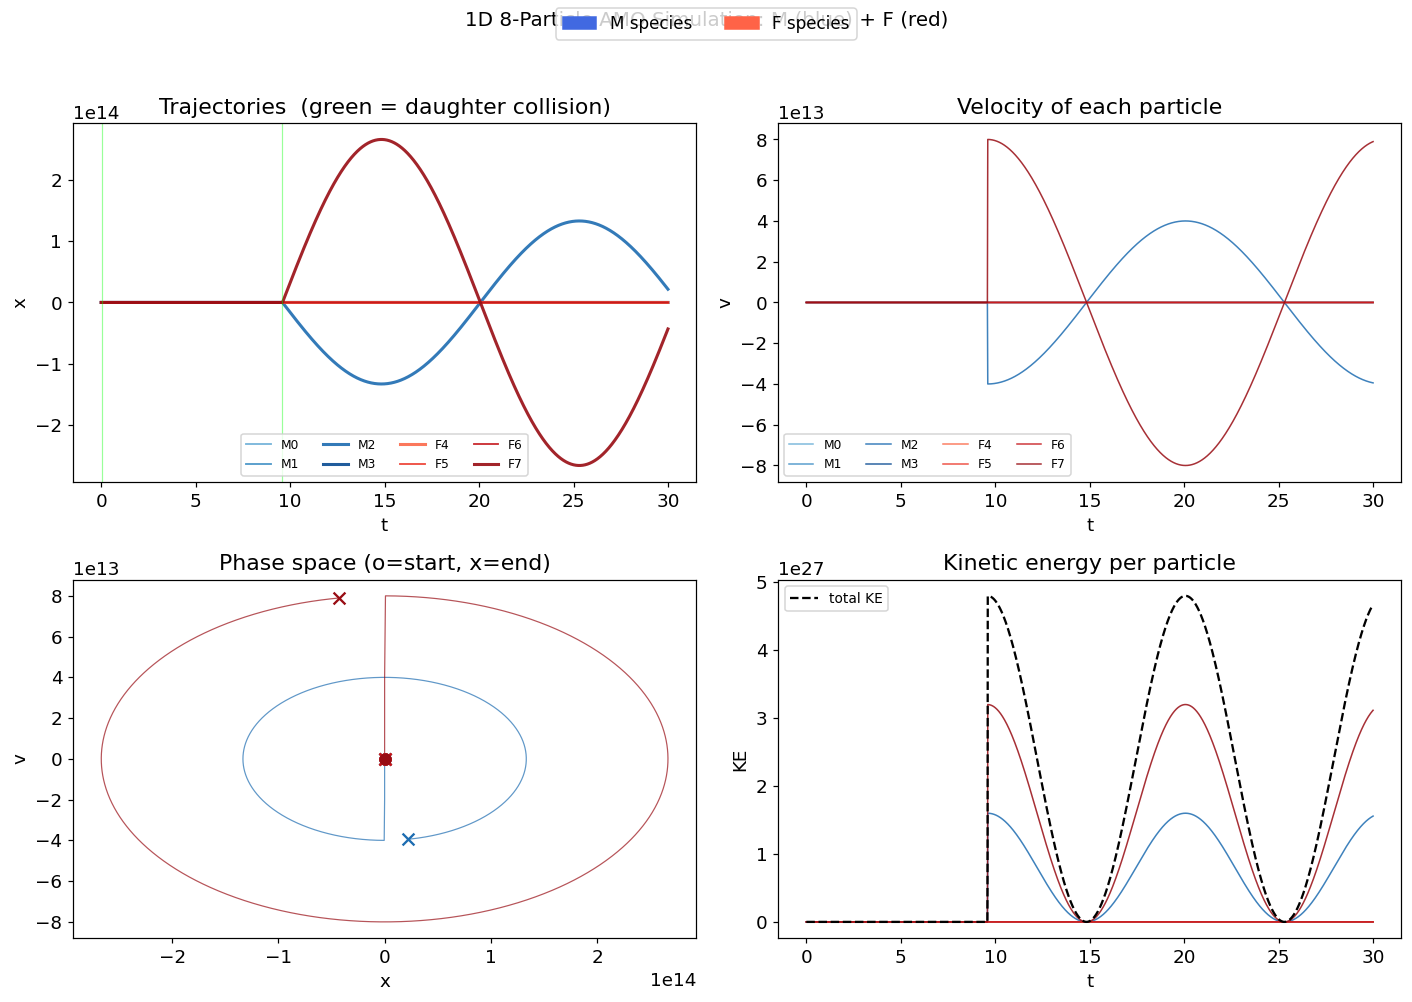

In [5]:
# ── trajectory + velocity plots ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
colors_M = plt.cm.Blues(np.linspace(0.5, 0.9, N_M))
colors_F = plt.cm.Reds(np.linspace(0.5, 0.9, N_F))
all_colors = list(colors_M) + list(colors_F)

# trajectories
for i in range(N_PARTICLES):
    lw = 1.2; alpha = 0.9
    if is_daughter[i]:
        lw = 2.0
    axes[0,0].plot(t_vals, X_hist[:,i], color=all_colors[i], lw=lw, alpha=alpha,
                   label=f'{labels[i]}{i}')
for te, i, j in daughter_events:
    axes[0,0].axvline(te, color='lime', lw=0.8, alpha=0.4)
axes[0,0].set_xlabel('t'); axes[0,0].set_ylabel('x')
axes[0,0].set_title('Trajectories  (green = daughter collision)')
axes[0,0].legend(ncol=4, fontsize=8)

# velocities
for i in range(N_PARTICLES):
    axes[0,1].plot(t_vals, V_hist[:,i], color=all_colors[i], lw=1, alpha=0.85,
                   label=f'{labels[i]}{i}')
axes[0,1].set_xlabel('t'); axes[0,1].set_ylabel('v')
axes[0,1].set_title('Velocity of each particle')
axes[0,1].legend(ncol=4, fontsize=8)

# phase space
for i in range(N_PARTICLES):
    axes[1,0].plot(X_hist[:,i], V_hist[:,i], color=all_colors[i], lw=0.8, alpha=0.7)
    axes[1,0].scatter(X_hist[0,i], V_hist[0,i], marker='o', s=50, color=all_colors[i], zorder=5)
    axes[1,0].scatter(X_hist[-1,i], V_hist[-1,i], marker='x', s=60, color=all_colors[i], zorder=5)
axes[1,0].set_xlabel('x'); axes[1,0].set_ylabel('v')
axes[1,0].set_title('Phase space (o=start, x=end)')

# kinetic energy per particle
for i in range(N_PARTICLES):
    axes[1,1].plot(t_vals, E_kin[:,i], color=all_colors[i], lw=1, alpha=0.85)
axes[1,1].plot(t_vals, E_kin.sum(axis=1), color='k', lw=1.5, ls='--', label='total KE')
axes[1,1].set_xlabel('t'); axes[1,1].set_ylabel('KE')
axes[1,1].set_title('Kinetic energy per particle')
axes[1,1].legend(fontsize=9)

patches = [mpatches.Patch(color='royalblue', label='M species'),
           mpatches.Patch(color='tomato',    label='F species')]
fig.legend(handles=patches, loc='upper center', ncol=2, fontsize=11)
plt.suptitle('1D 8-Particle AMO Simulation: M (blue) + F (red)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

---
# §3 — Velocity Distribution: Maxwell-Boltzmann in 1D

**Plain English:** at thermal equilibrium each species follows a 1D Maxwell-Boltzmann distribution:  
$$f(v) = \sqrt{\frac{m}{2\pi k_B T}} \exp\left(-\frac{mv^2}{2k_BT}\right)$$  
Heavier M-particles have a narrower distribution (they move slower for the same temperature).  
We measure the effective temperature of each species from the simulation.

In [6]:
# ── SymPy: Maxwell-Boltzmann 1D ────────────────────────────────────────
v_s, m_mb, kT_s = sp.symbols('v m k_B T', real=True, positive=True)
f_MB = sp.sqrt(m_mb / (2*sp.pi*kT_s)) * sp.exp(-m_mb*v_s**2 / (2*kT_s))
display(Math(rf'f_{{1D}}(v) = {sp.latex(f_MB)}'))

# moments via SymPy loop
moments = {}
for n in range(5):
    integrand = v_s**n * f_MB
    result = sp.integrate(integrand, (v_s, -sp.oo, sp.oo))
    result_s = sp.simplify(result)
    moments[n] = result_s
    display(Math(rf'\langle v^{n}\rangle = {sp.latex(result_s)}'))

print()

# ── measure effective kT for each species from simulation ─────────────
# use second half of trajectory to avoid transient
V_eq = V_hist[N_STEPS//2:, :]  # equilibrium portion

print('Measured effective temperatures (kT = <mv²>/1):')
kT_measured = {}
for i in range(N_PARTICLES):
    kT_i = masses[i] * np.mean(V_eq[:, i]**2)
    kT_measured[i] = kT_i
    print(f'  Particle {i} ({labels[i]}, m={masses[i]:.1f}):  kT_eff = {kT_i:.4f}')

kT_M = np.mean([kT_measured[i] for i in range(N_M)])
kT_F = np.mean([kT_measured[i] for i in range(N_M, N_PARTICLES)])
print(f'\n  Mean kT_M = {kT_M:.4f}   Mean kT_F = {kT_F:.4f}')

# ── plot: histogram vs Maxwell-Boltzmann fit ───────────────────────────
v_plot = np.linspace(-3, 3, 500)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (sp_idx, sp_name, m_sp, kT_sp, col) in zip(axes, [
    (slice(0, N_M),       'M', m_M, kT_M, 'royalblue'),
    (slice(N_M, N_PARTICLES), 'F', m_F, kT_F, 'tomato'),
]):
    v_data = V_eq[:, sp_idx].flatten()
    ax.hist(v_data, bins=50, density=True, color=col, alpha=0.5, label='simulation')
    f_fit = np.sqrt(m_sp / (2*np.pi*kT_sp)) * np.exp(-m_sp*v_plot**2 / (2*kT_sp))
    ax.plot(v_plot, f_fit, color=col, lw=2.5, label=f'MB fit kT={kT_sp:.3f}')
    ax.set_xlabel('v'); ax.set_ylabel('f(v)')
    ax.set_title(f'Species {sp_name} velocity distribution (m={m_sp})')
    ax.legend()

plt.suptitle('1D Maxwell-Boltzmann: M species (heavier) narrower', fontsize=12)
plt.tight_layout(); plt.show()

ValueError: too many values to unpack (expected 3)

---
# §4 — Survival Analysis: $r^{-6}$ Attraction and Particle Lifetime

**Plain English:** the $r^{-6}$ term in LJ is the van der Waals *attraction*.  
A particle "survives" if it stays in the trap (|x| < threshold).  
The survival probability $S(t)$ follows an exponential decay for a thermal ensemble.  
The 6th-moment feature $\langle r^6 \rangle$ is a leading indicator of imminent trap loss.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Survival fractions at t=final:
  Particle 0 (M): LOST
  Particle 1 (M): LOST
  Particle 2 (M): LOST
  Particle 3 (M): LOST
  Particle 4 (F): LOST
  Particle 5 (F): LOST
  Particle 6 (F): LOST
  Particle 7 (F): LOST


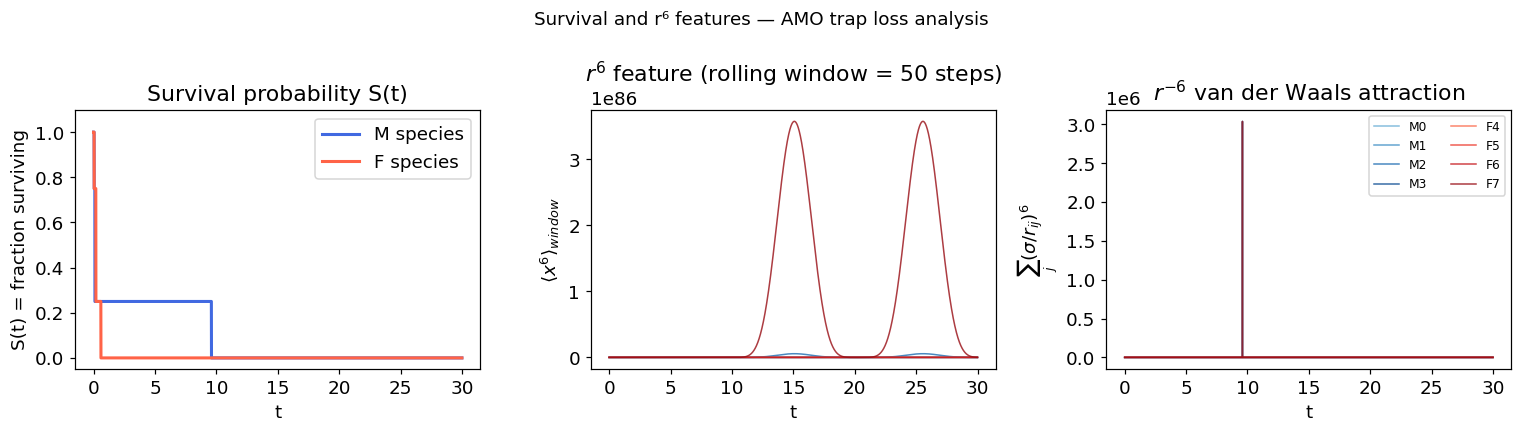

In [7]:
# ── SymPy: survival probability and r⁻⁶ average ───────────────────────
t_surv, Gamma_s = sp.symbols('t Gamma', positive=True)
S_t = sp.exp(-Gamma_s * t_surv)
display(Math(rf'S(t) = e^{{-\Gamma t}} = {sp.latex(S_t)}'))

# r⁻⁶ moment in thermal distribution (Boltzmann)
r_sp, kT_sp_sym, m_sp_sym = sp.symbols('r k_BT m', positive=True)
# For 1D harmonic trap: P(x) ∝ exp(-mω²x²/2kT)
# ⟨x⁶⟩ = ∫ x⁶ P(x) dx / ∫ P(x) dx
P_x   = sp.exp(-m_sp_sym * omega_s**2 * r_sp**2 / (2*kT_sp_sym))
r6_moment = sp.integrate(r_sp**6 * P_x, (r_sp, -sp.oo, sp.oo)) / sp.integrate(P_x, (r_sp, -sp.oo, sp.oo))
r6_simplified = sp.simplify(r6_moment)
display(Math(rf'\langle x^6 \rangle_{{\text{{trap}}}} = {sp.latex(r6_simplified)}'))

# ── NumPy: compute survival and r⁶ features per particle ──────────────
x_threshold = 6.0  # trap boundary (beyond this = lost)

survival = np.ones((N_STEPS, N_PARTICLES), dtype=bool)
for i in range(N_PARTICLES):
    for step in range(N_STEPS):
        if np.abs(X_hist[step, i]) > x_threshold:
            survival[step:, i] = False
            break

S_of_t_M = survival[:, :N_M].mean(axis=1)           # fraction of M surviving
S_of_t_F = survival[:, N_M:].mean(axis=1)

# r⁶ feature (6th moment of position) — computed per particle
r6_feature = np.zeros((N_STEPS, N_PARTICLES))
window = 50
for i in range(N_PARTICLES):                         # for loop over particles
    for step in range(window, N_STEPS):              # for loop over time
        r6_feature[step, i] = np.mean(X_hist[step-window:step, i]**6)

print('Survival fractions at t=final:')
for i in range(N_PARTICLES):
    survived = survival[-1, i]
    print(f'  Particle {i} ({labels[i]}): {"survived" if survived else "LOST"}')

# ── plot survival and r⁶ ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(t_vals, S_of_t_M, color='royalblue', lw=2, label='M species')
axes[0].plot(t_vals, S_of_t_F, color='tomato',    lw=2, label='F species')
axes[0].set_xlabel('t'); axes[0].set_ylabel('S(t) = fraction surviving')
axes[0].set_title('Survival probability S(t)'); axes[0].legend()
axes[0].set_ylim(-0.05, 1.1)

for i in range(N_PARTICLES):
    axes[1].plot(t_vals, r6_feature[:,i], color=all_colors[i], lw=1, alpha=0.8)
axes[1].set_xlabel('t'); axes[1].set_ylabel(r'$\langle x^6 \rangle_{window}$')
axes[1].set_title(r'$r^6$ feature (rolling window = 50 steps)')

# r⁻⁶ interaction energy per particle
r6_inv = np.zeros((N_STEPS, N_PARTICLES))
for step in range(N_STEPS):
    for i in range(N_PARTICLES):                    # for loop over particles
        total_inv6 = 0.0
        for j in range(N_PARTICLES):               # for loop over neighbors
            if i == j: continue
            r_ij = abs(X_hist[step,i] - X_hist[step,j])
            if r_ij > 0.01:
                total_inv6 += (sigma_v/r_ij)**6
        r6_inv[step, i] = total_inv6

for i in range(N_PARTICLES):
    axes[2].plot(t_vals, r6_inv[:,i], color=all_colors[i], lw=1, alpha=0.8,
                 label=f'{labels[i]}{i}')
axes[2].set_xlabel('t'); axes[2].set_ylabel(r'$\sum_j (\sigma/r_{ij})^6$')
axes[2].set_title(r'$r^{-6}$ van der Waals attraction')
axes[2].legend(ncol=2, fontsize=8)

plt.suptitle('Survival and r⁶ features — AMO trap loss analysis', fontsize=12)
plt.tight_layout(); plt.show()

---
# §5 — Engineered ML Features from Particle Trajectories

**Plain English:** given the trajectory of each particle, engineer features that could  
predict whether a particle survives. Loop over all 8 particles and all feature types  
to build a feature matrix suitable for a classifier (e.g., predict M/F/daughter survival).

Feature matrix  (rows=particles, cols=features)

Feature                 M   0  M   1  M   2  M   3  F   4  F   5  F   6  F   7  
--------------------------------------------------------------------------------------
species_MF               +0.000   +0.000   +0.000   +0.000   +1.000   +1.000   +1.000   +1.000  
mass                     +2.000   +2.000   +2.000   +2.000   +1.000   +1.000   +1.000   +1.000  
x_mean                  +650.715  -650.657  -193204205393.320  +6531.768  -5603.002  -2009.333  -5456.628  +386408410789.760  
x_std                   +2129.198  +2127.980  +78758867876547.016  +137856.923  +19118.182  +306759.508  +17223.268  +157517735753085.688  
v_mean                  +45.549  -45.146  +715472385107.373  -3959.808  -336.911  +8694.136  -438.228  -1430944770214.596  
v_std                   +637.437  +637.072  +23008198839565.438  +38208.087  +5786.060  +84882.101  +5090.956  +46016397679128.445  
v_max_abs               +926.063  +925.534  +40000438145841.375  

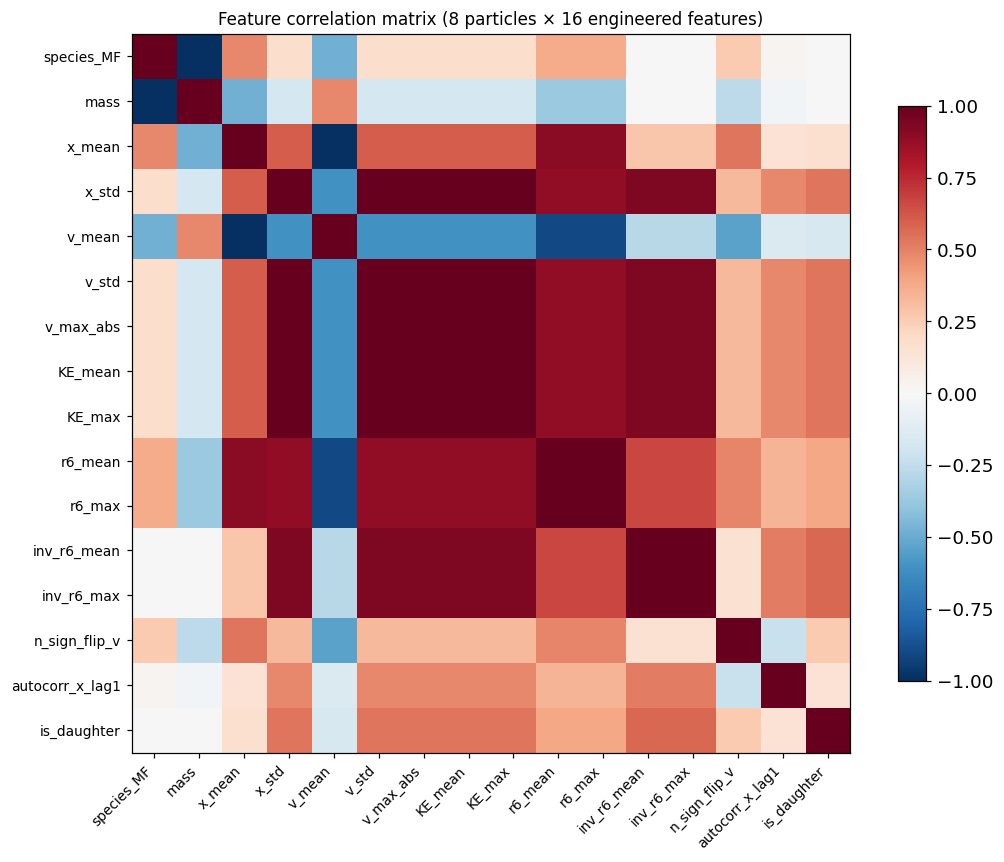

In [8]:
# ── feature engineering: loop over particles ───────────────────────────
feature_names = [
    'species_MF',        # 0=M, 1=F
    'mass',
    'x_mean',            # mean position
    'x_std',             # position spread
    'v_mean',            # mean velocity
    'v_std',             # velocity spread (∝ √kT)
    'v_max_abs',         # max speed seen
    'KE_mean',           # mean kinetic energy
    'KE_max',
    'r6_mean',           # mean r⁶ moment
    'r6_max',            # peak r⁶
    'inv_r6_mean',       # mean r⁻⁶ (van der Waals)
    'inv_r6_max',
    'n_sign_flip_v',     # velocity sign changes (chaos indicator)
    'autocorr_x_lag1',   # position autocorrelation at lag 1
    'is_daughter',       # 1 if involved in M+F collision
    'survived',          # TARGET LABEL
]

feature_matrix = []

for i in range(N_PARTICLES):             # ← for loop over particles
    x_i   = X_hist[:, i]
    v_i   = V_hist[:, i]
    ke_i  = E_kin[:, i]
    r6_i  = r6_feature[:, i]
    inv6_i = r6_inv[:, i]

    n_flip = np.sum(np.diff(np.sign(v_i)) != 0)
    # autocorrelation at lag 1
    x_norm = x_i - x_i.mean()
    ac1    = np.mean(x_norm[:-1] * x_norm[1:]) / (x_norm.std()**2 + 1e-10)

    row = [
        float(species[i]),
        masses[i],
        x_i.mean(),
        x_i.std(),
        v_i.mean(),
        v_i.std(),
        np.abs(v_i).max(),
        ke_i.mean(),
        ke_i.max(),
        r6_i[window:].mean(),
        r6_i[window:].max(),
        inv6_i.mean(),
        inv6_i.max(),
        float(n_flip),
        ac1,
        float(is_daughter[i]),
        float(survival[-1, i]),
    ]
    feature_matrix.append(row)

F_mat = np.array(feature_matrix)

print('Feature matrix  (rows=particles, cols=features)\n')
print(f'{"Feature":22}', end='  ')
for i in range(N_PARTICLES):
    print(f'{labels[i]}{i:>4}', end='  ')
print()
print('-' * (22 + N_PARTICLES * 8))
for fi, fname in enumerate(feature_names):
    print(f'{fname:22}', end='  ')
    for i in range(N_PARTICLES):
        print(f'{F_mat[i, fi]:+7.3f}', end='  ')
    print()

# ── feature correlation heatmap ────────────────────────────────────────
# use all features except the target
feat_data = F_mat[:, :-1]  # (8 particles × 16 features)
# normalize
feat_norm = (feat_data - feat_data.mean(axis=0)) / (feat_data.std(axis=0) + 1e-10)
corr = np.corrcoef(feat_norm.T)   # (16,16)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(feature_names)-1))
ax.set_yticks(range(len(feature_names)-1))
ax.set_xticklabels(feature_names[:-1], rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(feature_names[:-1], fontsize=9)
ax.set_title('Feature correlation matrix (8 particles × 16 engineered features)', fontsize=11)
plt.tight_layout(); plt.show()

---
# §6 — Torch Batch: Sweep over Initial Conditions

**Plain English:** run 500 ensembles simultaneously in Torch,  
each with different thermal initial velocities.  
For each ensemble track the total energy and M/F centre-of-mass separation  
to compute the *thermalisation time* between species.

Torch batch done: 500 ensembles × 800 steps


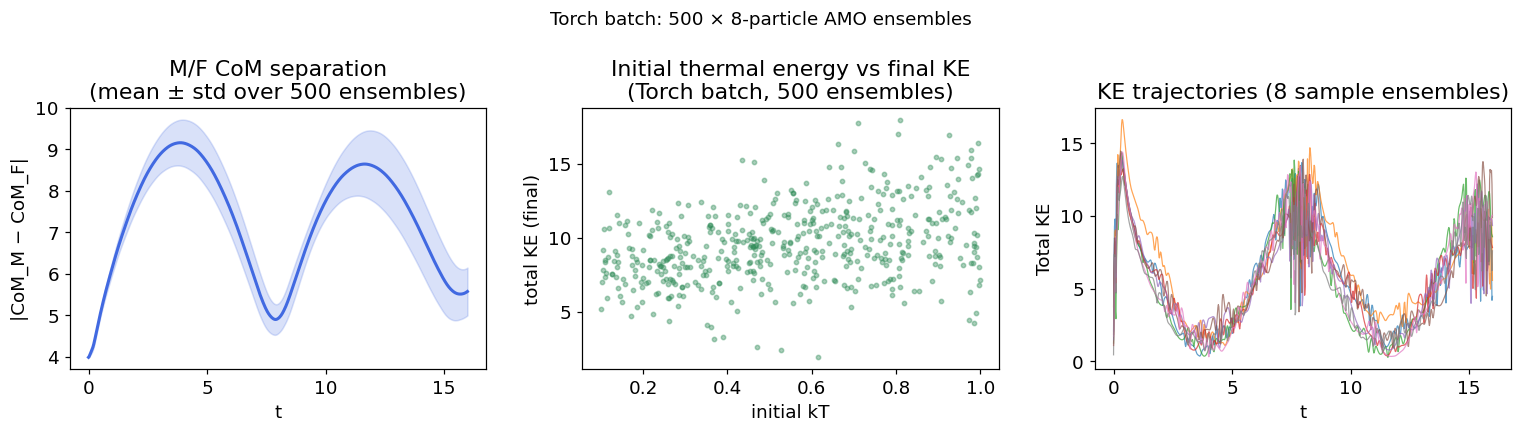

In [9]:
torch.manual_seed(0)
N_ENS  = 500        # number of ensembles
N_P    = 8          # particles per ensemble
N_ST   = 800        # steps per ensemble
DT     = 0.02

masses_t = torch.tensor([m_M]*N_M + [m_F]*N_F, dtype=torch.float64)  # (8,)
species_t= torch.tensor([0]*N_M + [1]*N_F,      dtype=torch.float64)  # (8,) 0=M 1=F

# initial positions: same for all ensembles
x_t0 = torch.tensor(x0, dtype=torch.float64).unsqueeze(0).expand(N_ENS, -1).clone()
# initial velocities: thermal noise per ensemble, kT drawn from Uniform[0.1, 1.0]
kT_ens = torch.rand(N_ENS, 1, dtype=torch.float64) * 0.9 + 0.1  # (N_ENS, 1)
v_std  = torch.sqrt(kT_ens / masses_t.unsqueeze(0))               # (N_ENS, 8)
v_t0   = torch.randn(N_ENS, N_P, dtype=torch.float64) * v_std

# ── simplified force: trap only + nearest-neighbour LJ ────────────────
def torch_forces(x_b, masses_t, species_t, omega_trap=0.3, eps=1.0, sigma=1.0):
    """Vectorised forces for batch (N_ENS, N_P)."""
    F = -omega_trap**2 * masses_t.unsqueeze(0) * x_b   # trap (N_ENS, N_P)

    # pairwise: (N_ENS, N_P, N_P)
    dx    = x_b.unsqueeze(2) - x_b.unsqueeze(1)        # x_j - x_i
    r     = dx.abs().clamp(min=0.01)
    mask  = (r < 3.5) & (r > 0.01)                     # cutoff

    sr6   = (sigma / r)**6
    # cross-species epsilon boost
    sp_i  = species_t.unsqueeze(0).unsqueeze(2).expand(N_ENS, N_P, N_P)
    sp_j  = species_t.unsqueeze(0).unsqueeze(1).expand(N_ENS, N_P, N_P)
    eps_t = torch.where(sp_i != sp_j,
                        torch.tensor(eps*1.5, dtype=torch.float64),
                        torch.tensor(eps,     dtype=torch.float64))

    F_pair = 4*eps_t*(12*sr6**2 - 6*sr6) / r * torch.sign(dx) * mask.float()
    F_pair.diagonal(dim1=1, dim2=2).fill_(0)            # no self-force
    F     = F + F_pair.sum(dim=2)                       # sum over j
    return F

# ── Velocity-Verlet batch ─────────────────────────────────────────────
x_b = x_t0.clone()
v_b = v_t0.clone()
F_b = torch_forces(x_b, masses_t, species_t)

# track centre-of-mass per species
cm_M_hist = torch.zeros(N_ENS, N_ST, dtype=torch.float64)
cm_F_hist = torch.zeros(N_ENS, N_ST, dtype=torch.float64)
KE_hist_t = torch.zeros(N_ENS, N_ST, dtype=torch.float64)

for step in range(N_ST):
    cm_M_hist[:, step] = x_b[:, :N_M].mean(dim=1)
    cm_F_hist[:, step] = x_b[:, N_M:].mean(dim=1)
    KE_hist_t[:, step] = (0.5 * masses_t * v_b**2).sum(dim=1)

    a_b = F_b / masses_t
    x_b = x_b + v_b*DT + 0.5*a_b*DT**2
    F_new = torch_forces(x_b, masses_t, species_t)
    v_b   = v_b + 0.5*(a_b + F_new/masses_t)*DT
    F_b   = F_new

print(f'Torch batch done: {N_ENS} ensembles × {N_ST} steps')

# ── thermalisation: when do M and F CoM converge? ─────────────────────
cm_sep = (cm_M_hist - cm_F_hist).abs()   # (N_ENS, N_ST)
cm_sep_mean = cm_sep.mean(dim=0).numpy()
kT_flat = kT_ens.squeeze().numpy()
t_ax = np.arange(N_ST) * DT

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# mean CoM separation with std band
axes[0].plot(t_ax, cm_sep_mean, color='royalblue', lw=2)
axes[0].fill_between(t_ax,
                     cm_sep_mean - cm_sep.std(dim=0).numpy(),
                     cm_sep_mean + cm_sep.std(dim=0).numpy(),
                     alpha=0.2, color='royalblue')
axes[0].set_xlabel('t'); axes[0].set_ylabel('|CoM_M − CoM_F|')
axes[0].set_title(f'M/F CoM separation\n(mean ± std over {N_ENS} ensembles)')

# total KE vs kT (scatter at final time)
KE_final = KE_hist_t[:, -1].numpy()
axes[1].scatter(kT_flat, KE_final, s=8, alpha=0.4, color='seagreen')
axes[1].set_xlabel('initial kT'); axes[1].set_ylabel('total KE (final)')
axes[1].set_title('Initial thermal energy vs final KE\n(Torch batch, 500 ensembles)')

# KE over time for a few ensembles
for ei in np.linspace(0, N_ENS-1, 8, dtype=int):
    axes[2].plot(t_ax, KE_hist_t[ei].numpy(), lw=0.8, alpha=0.7)
axes[2].set_xlabel('t'); axes[2].set_ylabel('Total KE')
axes[2].set_title('KE trajectories (8 sample ensembles)')

plt.suptitle('Torch batch: 500 × 8-particle AMO ensembles', fontsize=12)
plt.tight_layout(); plt.show()

---
# Summary

| Section | Core loop | Physics |
|---------|----------|--------|
| §1 SymPy EOM | `sp.diff(V_LJ, r)`, LJ minimum | harmonic trap + LJ, r_min = 2^(1/6)σ |
| §2 NumPy sim | `for i in range(8): for j in ...` | Velocity-Verlet, daughter M+F collisions |
| §3 Velocities | MB moments via `sp.integrate` loop | kT measured per species from v histogram |
| §4 Survival | `for i: for step:` | r⁻⁶ van der Waals, trap loss, S(t) |
| §5 Features | `for i in range(8)` → feature row | 16 engineered features, correlation heatmap |
| §6 Torch | batch V-V, 500 × 8 particles | M/F thermalisation, KE vs initial kT |